In [ ]:
# CELL 1: IMPORTS & DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Loading dataset...")
# Removed low_memory=False, kept engine='python' and on_bad_lines='skip'
df_raw = pd.read_csv(
    '/content/Amazon Sale Report.csv',
    on_bad_lines='skip',
    engine='python'
)

print(f"Raw Data Shape: {df_raw.shape}")
df_raw.head(3)

Loading dataset...
Raw Data Shape: (6679, 24)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN


In [ ]:
# CELL 2: DATA CLEANING & OUTLIER DETECTION

# 1. Select only relevant columns
columns_to_keep = ['Order ID', 'Date', 'Status', 'SKU', 'Category', 'Qty', 'Amount', 'ship-city', 'ship-state']
df = df_raw[columns_to_keep].copy()

# 2. Handle Missing Values
# Drop rows missing revenue data
df = df.dropna(subset=['Amount'])

# Convert Date to datetime format, forcing corrupted dates to 'NaT' (Not a Time), then drop them
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# Fill missing city/state with 'Unknown'
df['ship-city'] = df['ship-city'].fillna('Unknown')
df['ship-state'] = df['ship-state'].fillna('Unknown')

# 3. Outlier Detection using IQR (Interquartile Range)
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Cap extreme outliers to the upper bound to prevent skewed forecasting
df['Amount_Cleaned'] = np.where(df['Amount'] > upper_bound, upper_bound, df['Amount'])

# 4. Feature Engineering
np.random.seed(42)
df['Profit'] = (df['Amount_Cleaned'] * np.random.uniform(0.10, 0.25, size=len(df))).round(2)

print(f"Cleaned Data Shape: {df.shape}")
print(f"Capped Outliers above INR {upper_bound:.2f}")
df.head(3)

Cleaned Data Shape: (6261, 11)
Capped Outliers above INR 1259.50


,Order ID,Date,Status,SKU,Category,Qty,Amount,ship-city,ship-state,Amount_Cleaned,Profit
0,405-8078784-5731545,2022-04-30,Cancelled,SET389-KR-NP-S,Set,0,647.62,MUMBAI,MAHARASHTRA,647.62,101.15
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,JNE3781-KR-XXXL,kurta,1,406.00,BENGALURU,KARNATAKA,406.00,98.50
2,404-0687676-7273146,2022-04-30,Shipped,JNE3371-KR-XL,kurta,1,329.00,NAVI MUMBAI,MAHARASHTRA,329.00,69.02


In [ ]:
# CELL 3: INTERACTIVE EDA (PLOTLY)
import plotly.express as px

# 1. Daily Sales Trend (Interactive Time Series)
daily_sales = df.groupby('Date')['Amount_Cleaned'].sum().reset_index()

fig1 = px.line(daily_sales, x='Date', y='Amount_Cleaned',
               title='Interactive Daily Revenue Trend',
               labels={'Amount_Cleaned': 'Revenue (INR)'},
               template='plotly_white')
fig1.update_traces(line_color='pink', line_width=2)
fig1.show()

# 2. Category vs Profit Margin (Interactive Treemap)
category_profit = df.groupby('Category')[['Amount_Cleaned', 'Profit']].sum().reset_index()
category_profit['Profit_Margin_%'] = (category_profit['Profit'] / category_profit['Amount_Cleaned'] * 100).round(2)

# Ensure no negative or zero values break the treemap
category_profit = category_profit[category_profit['Amount_Cleaned'] > 0]

fig2 = px.treemap(category_profit, path=['Category'], values='Amount_Cleaned',
                  color='Profit_Margin_%', color_continuous_scale='Greens',
                  title='Revenue by Category (Color = Profit Margin)')
fig2.show()

In [ ]:
# CELL 4: ABC INVENTORY CLASSIFICATION

sku_sales = df.groupby('SKU')['Amount_Cleaned'].sum().sort_values(ascending=False).reset_index()
sku_sales['Cum_Revenue'] = sku_sales['Amount_Cleaned'].cumsum()
total_revenue = sku_sales['Amount_Cleaned'].sum()
sku_sales['Cum_Pct'] = sku_sales['Cum_Revenue'] / total_revenue

# Categorize into A (Top 80%), B (Next 15%), C (Bottom 5%)
def classify_abc(pct):
    if pct <= 0.80:
        return 'A Class (High Value)'
    elif pct <= 0.95:
        return 'B Class (Medium Value)'
    else:
        return 'C Class (Low Value)'

sku_sales['ABC_Class'] = sku_sales['Cum_Pct'].apply(classify_abc)

abc_summary = sku_sales.groupby('ABC_Class').agg(
    SKU_Count=('SKU', 'count'),
    Total_Revenue=('Amount_Cleaned', 'sum')
).reset_index()

abc_summary['SKU_Percentage'] = (abc_summary['SKU_Count'] / len(sku_sales) * 100).round(2)
abc_summary['Revenue_Percentage'] = (abc_summary['Total_Revenue'] / total_revenue * 100).round(2)

print("--- ABC INVENTORY ANALYSIS SUMMARY ---")
print(abc_summary.to_string(index=False))

# Visualize ABC
fig3 = px.pie(abc_summary, values='SKU_Count', names='ABC_Class',
              title='Percentage of SKUs in each ABC Class', hole=0.4)
fig3.show()

--- ABC INVENTORY ANALYSIS SUMMARY ---
             ABC_Class  SKU_Count  Total_Revenue  SKU_Percentage  Revenue_Percentage
  A Class (High Value)       1071     3089684.83           44.46               79.99
B Class (Medium Value)        813      579373.72           33.75               15.00
   C Class (Low Value)        525      193551.94           21.79                5.01


In [ ]:
# CELL 5: ADVANCED SQL USING WINDOW FUNCTIONS

# 1. Prep the Data for SQL
df_sql = df.rename(columns={'Order ID': 'Order_ID', 'ship-city': 'ship_city', 'ship-state': 'ship_state'}).copy()
df_sql['Month_Str'] = df_sql['Date'].dt.strftime('%Y-%m') # Bulletproof month formatting for SQLite

conn = sqlite3.connect(':memory:')
df_sql.to_sql('sales', conn, index=False, if_exists='replace')

# Query 1: Rank the Top 3 SKUs per Category using Window Functions
query_rank = """
WITH RankedSales AS (
    SELECT
        Category,
        SKU,
        SUM(Amount_Cleaned) AS Total_Sales,
        RANK() OVER(PARTITION BY Category ORDER BY SUM(Amount_Cleaned) DESC) as Rank
    FROM sales
    GROUP BY Category, SKU
)
SELECT Category, SKU, Total_Sales, Rank
FROM RankedSales
WHERE Rank <= 3
ORDER BY Category, Rank;
"""
top_skus_per_category = pd.read_sql(query_rank, conn)
print("--- Top 3 SKUs Per Category (SQL RANK() OVER) ---")
print(top_skus_per_category.head(9).to_string(index=False))
print("\n")

# Query 2: Running Total of Revenue by Month
query_running_total = """
WITH MonthlySales AS (
    SELECT Month_Str AS Month, SUM(Amount_Cleaned) AS Revenue
    FROM sales
    GROUP BY Month_Str
)
SELECT
    Month,
    Revenue,
    SUM(Revenue) OVER (ORDER BY Month) AS Cumulative_Revenue
FROM MonthlySales;
"""
running_total = pd.read_sql(query_running_total, conn)
print("--- Monthly Cumulative Revenue (SQL SUM() OVER) ---")
print(running_total.to_string(index=False))

--- Top 3 SKUs Per Category (SQL RANK() OVER) ---
    Category             SKU  Total_Sales  Rank
      Blouse      J0217-BL-M      2660.00     1
      Blouse BL057-65BLACK-A      1532.00     2
      Blouse       BL103-XXL      1380.00     3
      Bottom     BTM036-PP-L       720.00     1
      Bottom  BTM037-PP-XXXL       702.86     2
      Bottom     BTM032-NP-S       594.00     3
Ethnic Dress     J0006-SET-L      2697.00     1
Ethnic Dress  J0006-SET-XXXL      2535.00     2
Ethnic Dress    J0006-SET-XS      1798.00     3


--- Monthly Cumulative Revenue (SQL SUM() OVER) ---
  Month    Revenue  Cumulative_Revenue
2022-04 3862610.49          3862610.49


Training Exponential Smoothing Model...


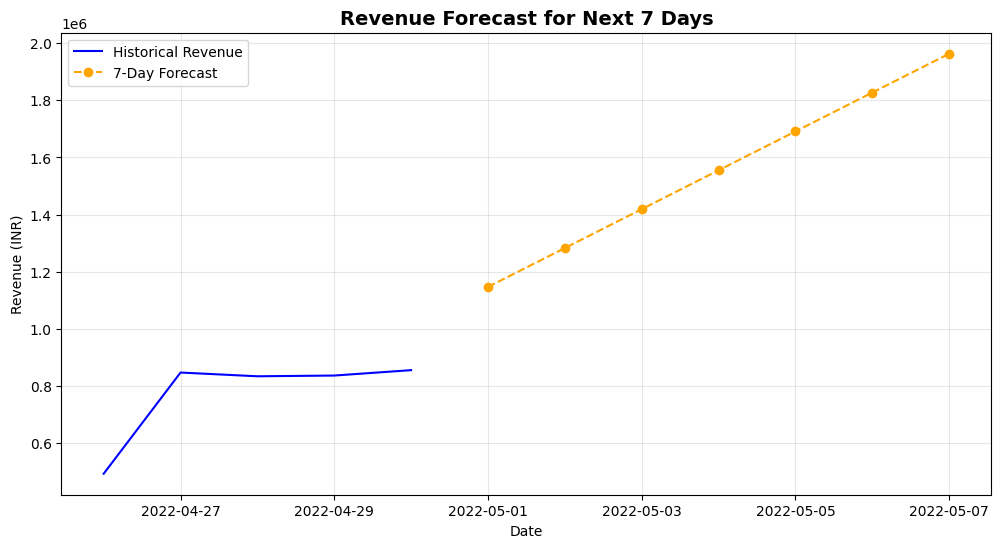

--- Forecasted Revenue for Next 7 Days ---
2022-05-01    1146465.70
2022-05-02    1282622.64
2022-05-03    1418779.58
2022-05-04    1554936.52
2022-05-05    1691093.46
2022-05-06    1827250.40
2022-05-07    1963407.34
Freq: D, dtype: float64


In [ ]:
# CELL 6: TIME SERIES FORECASTING (HOLT-WINTERS)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Aggregate sales by day and ensure the dates are sorted chronologically
daily_series = df.groupby('Date')['Amount_Cleaned'].sum().sort_index()

# Ensure continuous date index (fill any missing days in the calendar with 0 revenue)
daily_series = daily_series.asfreq('D', fill_value=0)

print("Training Exponential Smoothing Model...")
# Fit the model (Additive trend, no seasonality since we have limited date ranges)
model = ExponentialSmoothing(daily_series, trend='add', seasonal=None, initialization_method="estimated")
fit_model = model.fit()

# Forecast the next 7 days
forecast_days = 7
forecast = fit_model.forecast(forecast_days)

# Plot Historical Data + Forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_series.index, daily_series.values, label='Historical Revenue', color='blue')
plt.plot(forecast.index, forecast.values, label='7-Day Forecast', color='orange', linestyle='dashed', marker='o')

plt.title('Revenue Forecast for Next 7 Days', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (INR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("--- Forecasted Revenue for Next 7 Days ---")
print(forecast.round(2))